# Step 5: Temporal Fusion Transformer for Concentration Prediction

This notebook implements and evaluates a Temporal Fusion Transformer (TFT) for predicting fermentation concentration at arbitrary time T+D given process signals up to time T.

## Features
- **Probabilistic predictions**: Outputs (μ, σ) for uncertainty quantification
- **Interpretability**: Variable importance via VSN weights and temporal attention heatmaps
- **Variable horizons**: Predict at any future time D
- **28 input channels**: 25 process signals + 3 concentration-related channels

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from tqdm.auto import tqdm

from src.data_loader import load_batches, get_batch_info
from src.domain_splits import get_control_mode_split
from src.tft_model import (
    TemporalFusionTransformer,
    GaussianNLLLoss,
    create_tft_model,
    count_parameters,
)
from src.tft_dataset import (
    create_tft_dataloaders,
    TFTConcentrationDataset,
)
from src.train import EarlyStopping
from src.preprocessing import denormalize_target, TARGET_MIN, TARGET_MAX

# Set random seeds
torch.manual_seed(42)
np.random.seed(42)

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: mps


## 1. Data Loading and Preprocessing

In [2]:
# Load batches
batches = load_batches()
batch_info = get_batch_info(batches)
print(f'Loaded {len(batches)} batches')
batch_info.head(10)

Loaded 100 batches


,batch_id,length,duration_h,control_mode,is_fault,p_conc
0,1,1130,225.8,recipe,False,29.3730
1,2,1150,229.8,recipe,False,30.4160
2,3,1390,277.8,recipe,False,17.4280
3,4,1150,229.8,recipe,False,15.1070
4,5,895,178.8,recipe,False,28.1720
5,6,1150,229.8,recipe,False,13.3660
6,7,1160,231.8,recipe,False,29.4160
7,8,1150,229.8,recipe,False,34.5080
8,9,1260,251.8,recipe,False,6.6957
9,10,1150,229.8,recipe,False,15.4110


In [3]:
# Get domain splits
split = get_control_mode_split("1c")  # Recipe (1-30) vs operator (31-60) vs APC (61-90)
source_ids = split["source"]
target_ids = split["target"]
print(f'Source batches: {len(source_ids)}')
print(f'Target batches: {len(target_ids)}')

Source batches: 60
Target batches: 30


In [20]:
# Create TFT DataLoaders
data = create_tft_dataloaders(
    source_ids=source_ids,
    target_ids=target_ids,
    batches=batches,
    val_ratio=0.2,
    batch_size=8,
    max_seq_len=1000,
    min_T_fraction=0.3,
    max_T_fraction=0.9,
    min_D_hours=0.0,
    max_D_hours=20.0,
    samples_per_batch=100, # number of random (T, D) samples from each experiment batch
    n_T_values=32,
    seed=123,
)

print(f'Source samples: {len(data["train_dataset"])}')
print(f'Source - Training samples: {len(data["train"])}')
print(f'Source - Validation samples: {len(data["val"])}')
print(f'Target samples: {len(data["target_dataset"])}')
print(f'Number of features: {data["n_features"]}')

Source samples: 3096
Source - Training samples: 395
Source - Validation samples: 111
Target samples: 2484
Number of features: 28


Batch shapes:
  x: torch.Size([8, 479, 28])
  y: torch.Size([8])
  mask: torch.Size([8, 479])
  D_steps: tensor([14, 73, 86, 22, 78])


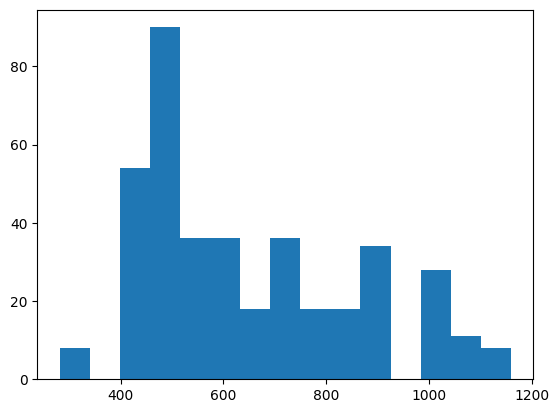

In [21]:
# Inspect a batch
for batch in data['train']:
    print('Batch shapes:')
    print(f'  x: {batch["x"].shape}')
    print(f'  y: {batch["y"].shape}')
    print(f'  mask: {batch["mask"].shape}')
    print(f'  D_steps: {batch["D_steps"][:5]}')
    break

lens = []
for b in data['train']:
    lens.append(b["x"].shape[1])
plt.hist(lens, 15);

## 2. Model Definition

In [22]:
# Model configuration
model_config = {
    'd_model': 64, # Per-variable embedding dim at each time point
    'd_hidden': 64,
    'n_lstm_layers': 2,
    'n_attention_heads': 8,
    'dropout': 0.1,
    'max_horizon': 1000,
}

model = create_tft_model(n_features=data['n_features'], config=model_config)
model = model.to(device)

print(f'Model parameters: {count_parameters(model):,}')
print(f'Model architecture:\n{model}')

Model parameters: 681,422
Model architecture:
TemporalFusionTransformer(
  (var_embeddings): ModuleList(
    (0-27): 28 x Linear(in_features=1, out_features=64, bias=True)
  )
  (vsn): VariableSelectionNetwork(
    (variable_grns): ModuleList(
      (0-27): 28 x GatedResidualNetwork(
        (skip_proj): Identity()
        (fc1): Linear(in_features=64, out_features=64, bias=True)
        (fc2): Linear(in_features=64, out_features=128, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (layer_norm): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      )
    )
    (selection_grn): GatedResidualNetwork(
      (skip_proj): Linear(in_features=1792, out_features=28, bias=True)
      (fc1): Linear(in_features=1792, out_features=64, bias=True)
      (fc2): Linear(in_features=64, out_features=56, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
      (layer_norm): LayerNorm((28,), eps=1e-05, elementwise_affine=True)
    )
  )
  (lstm): LSTM(64, 32, num_layers=2, 

In [23]:
# Sanity check: forward pass
model.eval()
with torch.no_grad():
    for batch in data['train']:
        x = batch['x'].to(device)
        horizon = batch['D_steps'].to(device)
        mask = batch['mask'].to(device)
        
        mu, sigma = model(x, horizon, mask=mask)
        print(f'Input shape: {x.shape}')
        print(f'Output mu shape: {mu.shape}')
        print(f'Output sigma shape: {sigma.shape}')
        print(f'Sigma range: [{sigma.min():.4f}, {sigma.max():.4f}]')
        break

Input shape: torch.Size([8, 529, 28])
Output mu shape: torch.Size([8])
Output sigma shape: torch.Size([8])
Sigma range: [0.5680, 0.8240]


## 2.1 MPS GPU Profiling

Profile the TFT model to find the optimal batch size for MPS GPU utilization.
Measures memory usage and compute throughput across batch sizes.

In [8]:
import time


def profile_tft_config(
    n_features: int,
    batch_size: int,
    seq_len: int,
    model_config: dict,
    device: torch.device,
    n_warmup: int = 3,
    n_repeats: int = 3,
) -> dict:
    """Profile TFT model for a given config and batch size.

    Runs synthetic forward+backward passes and measures memory and throughput.

    Returns dict with: param_memory_mb, fwd_peak_mb, bwd_peak_mb,
    driver_memory_mb, fwd_ms, bwd_ms, throughput_samples_sec.
    """
    is_mps = device.type == "mps"

    # Clean slate
    if is_mps:
        torch.mps.synchronize()
        torch.mps.empty_cache()

    # Create model
    m = create_tft_model(n_features=n_features, config=model_config).to(device)
    m.train()

    # Parameter memory
    param_bytes = sum(p.numel() * p.element_size() for p in m.parameters())
    param_mb = param_bytes / 1024**2

    # Synthetic data
    x = torch.randn(batch_size, seq_len, n_features, device=device)
    horizon = torch.randint(0, model_config.get("max_horizon", 500), (batch_size,), device=device)
    y = torch.randn(batch_size, device=device)

    loss_fn = GaussianNLLLoss()
    optimizer = torch.optim.AdamW(m.parameters(), lr=1e-4)

    # Warmup (GPU kernels compile lazily on MPS)
    for _ in range(n_warmup):
        optimizer.zero_grad()
        mu, sigma = m(x, horizon)
        loss = loss_fn(mu, sigma, y)
        loss.backward()
        optimizer.step()

    if is_mps:
        torch.mps.synchronize()
        torch.mps.empty_cache()

    # Memory after warmup (model + optimizer state loaded)
    base_mem = torch.mps.current_allocated_memory() if is_mps else 0

    # Timed forward passes
    fwd_times = []
    fwd_peak = 0
    for _ in range(n_repeats):
        if is_mps:
            torch.mps.synchronize()
        t0 = time.perf_counter()
        mu, sigma = m(x, horizon)
        if is_mps:
            torch.mps.synchronize()
        fwd_times.append(time.perf_counter() - t0)
        if is_mps:
            fwd_peak = max(fwd_peak, torch.mps.current_allocated_memory())

    fwd_peak_mb = fwd_peak / 1024**2

    # Timed backward passes
    bwd_times = []
    bwd_peak = 0
    for _ in range(n_repeats):
        optimizer.zero_grad()
        mu, sigma = m(x, horizon)
        loss = loss_fn(mu, sigma, y)
        if is_mps:
            torch.mps.synchronize()
        t0 = time.perf_counter()
        loss.backward()
        if is_mps:
            torch.mps.synchronize()
        bwd_times.append(time.perf_counter() - t0)
        if is_mps:
            bwd_peak = max(bwd_peak, torch.mps.current_allocated_memory())

    bwd_peak_mb = bwd_peak / 1024**2
    driver_mb = (torch.mps.driver_allocated_memory() / 1024**2) if is_mps else 0

    fwd_ms = np.median(fwd_times) * 1000
    bwd_ms = np.median(bwd_times) * 1000
    total_ms = fwd_ms + bwd_ms
    throughput = batch_size / (total_ms / 1000) if total_ms > 0 else 0

    # Cleanup
    del m, x, horizon, y, optimizer
    if is_mps:
        torch.mps.synchronize()
        torch.mps.empty_cache()

    return {
        "batch_size": batch_size,
        "param_memory_mb": round(param_mb, 2),
        "fwd_peak_mb": round(fwd_peak_mb, 2),
        "bwd_peak_mb": round(bwd_peak_mb, 2),
        "driver_memory_mb": round(driver_mb, 2),
        "fwd_ms": round(fwd_ms, 2),
        "bwd_ms": round(bwd_ms, 2),
        "throughput_samples_sec": round(throughput, 1),
    }


print("profile_tft_config() defined")

profile_tft_config() defined


In [9]:
def sweep_batch_sizes(
    n_features: int,
    seq_len: int,
    model_config: dict,
    device: torch.device,
    batch_sizes: list[int] | None = None,
    n_warmup: int = 3,
    n_repeats: int = 10,
) -> pd.DataFrame:
    """Sweep batch sizes and profile each one.

    Stops gracefully on OOM. Returns DataFrame with profiling results.
    """
    if batch_sizes is None:
        batch_sizes = [1, 2, 4, 8, 12, 16, 20, 24, 28, 32]

    results = []
    for bs in batch_sizes:
        print(f"Profiling batch_size={bs} ...", end=" ", flush=True)
        try:
            r = profile_tft_config(
                n_features=n_features,
                batch_size=bs,
                seq_len=seq_len,
                model_config=model_config,
                device=device,
                n_warmup=n_warmup,
                n_repeats=n_repeats,
            )
            results.append(r)
            print(
                f"fwd={r['fwd_ms']:.1f}ms  bwd={r['bwd_ms']:.1f}ms  "
                f"throughput={r['throughput_samples_sec']:.0f} samples/s  "
                f"mem={r['driver_memory_mb']:.0f}MB"
            )
        except RuntimeError as e:
            if "out of memory" in str(e).lower() or "MPS" in str(e):
                print(f"OOM — stopping sweep.")
                if device.type == "mps":
                    torch.mps.synchronize()
                    torch.mps.empty_cache()
                break
            raise

    return pd.DataFrame(results)


print("sweep_batch_sizes() defined")

sweep_batch_sizes() defined


In [10]:
# Run batch size sweep with current model config
results = sweep_batch_sizes(
    n_features=data['n_features'],
    seq_len=500,  # representative sequence length
    model_config=model_config,
    device=device,
)
results

Profiling batch_size=1 ... fwd=30.0ms  bwd=56.3ms  throughput=12 samples/s  mem=270MB
Profiling batch_size=2 ... fwd=31.5ms  bwd=71.4ms  throughput=19 samples/s  mem=1361MB
Profiling batch_size=4 ... fwd=39.2ms  bwd=95.8ms  throughput=30 samples/s  mem=1568MB
Profiling batch_size=8 ... fwd=67.1ms  bwd=150.8ms  throughput=37 samples/s  mem=1773MB
Profiling batch_size=12 ... fwd=94.5ms  bwd=217.8ms  throughput=38 samples/s  mem=2518MB
Profiling batch_size=16 ... fwd=120.9ms  bwd=270.8ms  throughput=41 samples/s  mem=3363MB
Profiling batch_size=20 ... fwd=153.8ms  bwd=326.5ms  throughput=42 samples/s  mem=3437MB
Profiling batch_size=24 ... fwd=184.8ms  bwd=394.5ms  throughput=41 samples/s  mem=3914MB
Profiling batch_size=28 ... fwd=220.2ms  bwd=451.1ms  throughput=42 samples/s  mem=4601MB
Profiling batch_size=32 ... fwd=550.0ms  bwd=672.6ms  throughput=26 samples/s  mem=5842MB


,batch_size,param_memory_mb,fwd_peak_mb,bwd_peak_mb,driver_memory_mb,fwd_ms,bwd_ms,throughput_samples_sec
0,1,2.6,118.01,26.63,270.42,29.97,56.33,11.6
1,2,2.6,227.62,40.40,1361.22,31.47,71.42,19.4
2,4,2.6,442.05,69.91,1568.02,39.17,95.79,29.6
3,8,2.6,688.78,81.14,1772.94,67.07,150.85,36.7
4,12,2.6,820.26,14.61,2517.73,94.52,217.80,38.4
5,16,2.6,1050.28,15.14,3362.53,120.87,270.78,40.9
6,20,2.6,1311.03,14.97,3437.33,153.80,326.46,41.6
7,24,2.6,1570.70,15.44,3914.25,184.76,394.48,41.4
8,28,2.6,1830.37,15.91,4601.05,220.25,451.09,41.7
9,32,2.6,2090.03,16.37,5841.84,549.95,672.64,26.2


NameError: name 'results' is not defined

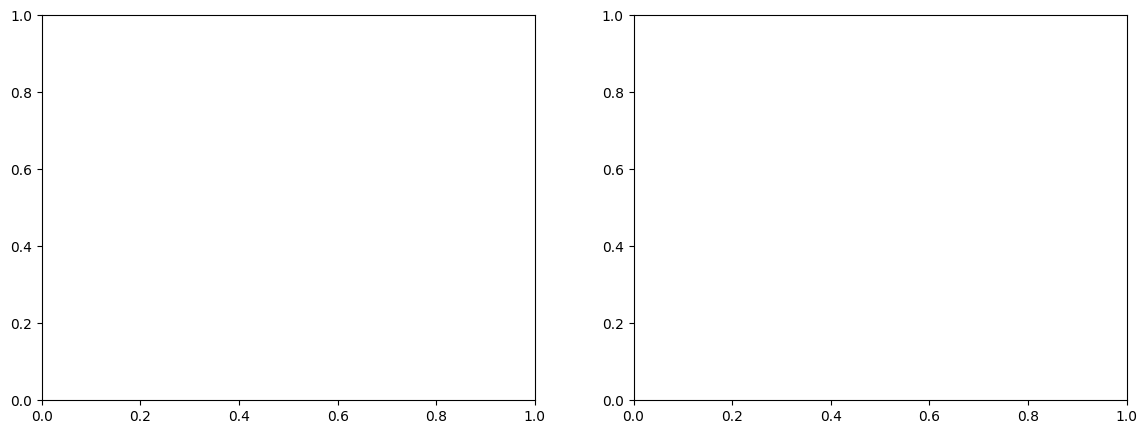

In [8]:
# Visualize profiling results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

batch_sizes = results['batch_size']

# Left panel: Memory vs batch size
ax = axes[0]
ax.bar(range(len(batch_sizes)), results['fwd_peak_mb'], label='Forward peak', alpha=0.8)
ax.bar(range(len(batch_sizes)), results['bwd_peak_mb'] - results['fwd_peak_mb'],
       bottom=results['fwd_peak_mb'], label='Backward (additional)', alpha=0.8)
ax.set_xticks(range(len(batch_sizes)))
ax.set_xticklabels(batch_sizes)
ax.set_xlabel('Batch Size')
ax.set_ylabel('Peak Memory (MB)')
ax.set_title('MPS Memory Usage vs Batch Size')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Right panel: Throughput vs batch size
ax = axes[1]
throughput = results['throughput_samples_sec']
ax.plot(range(len(batch_sizes)), throughput, 'o-', color='tab:green', linewidth=2, markersize=8)

# Mark the sweet spot (highest throughput)
best_idx = throughput.idxmax()
ax.axvline(x=best_idx, color='red', linestyle='--', alpha=0.6, label=f'Best: bs={batch_sizes.iloc[best_idx]}')
ax.annotate(
    f'{throughput.iloc[best_idx]:.0f} samples/s',
    xy=(best_idx, throughput.iloc[best_idx]),
    xytext=(10, 10), textcoords='offset points',
    fontsize=10, fontweight='bold', color='red',
    arrowprops=dict(arrowstyle='->', color='red'),
)

ax.set_xticks(range(len(batch_sizes)))
ax.set_xticklabels(batch_sizes)
ax.set_xlabel('Batch Size')
ax.set_ylabel('Throughput (samples/sec)')
ax.set_title('Training Throughput vs Batch Size')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print recommendation
best_bs = batch_sizes.iloc[best_idx]
best_tp = throughput.iloc[best_idx]
current_bs = 16
current_tp = throughput[batch_sizes == current_bs].values
speedup = best_tp / current_tp[0] if len(current_tp) > 0 else float('nan')

print(f"\n{'='*50}")
print(f"Recommendation: batch_size={best_bs}")
print(f"  Peak throughput: {best_tp:.0f} samples/sec")
if not np.isnan(speedup):
    print(f"  Speedup vs current (bs={current_bs}): {speedup:.2f}x")
print(f"  Peak memory: {results['driver_memory_mb'].iloc[best_idx]:.0f} MB")
print(f"{'='*50}")

## 3. Training

In [24]:
def train_tft_epoch(
    model,
    train_loader,
    optimizer,
    loss_fn,
    device,
):
    """Train for one epoch."""
    model.train()
    total_loss = 0.0
    n_batches = 0
    
    for batch in train_loader:
        x = batch['x'].to(device)
        y = batch['y'].to(device)
        horizon = batch['D_steps'].to(device)
        mask = batch['mask'].to(device)
        
        optimizer.zero_grad()
        mu, sigma = model(x, horizon, mask=mask)
        loss = loss_fn(mu, sigma, y)
        loss.backward()
        
        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        total_loss += loss.item()
        n_batches += 1
    
    return total_loss / n_batches


def evaluate_tft(
    model,
    data_loader,
    loss_fn,
    device,
):
    """Evaluate model."""
    model.eval()
    total_loss = 0.0
    all_mu = []
    all_sigma = []
    all_y = []
    n_samples = 0
    
    with torch.no_grad():
        for batch in data_loader:
            x = batch['x'].to(device)
            y = batch['y'].to(device)
            horizon = batch['D_steps'].to(device)
            mask = batch['mask'].to(device)
            
            mu, sigma = model(x, horizon, mask=mask)
            loss = loss_fn(mu, sigma, y)
            
            total_loss += loss.item() * len(y)
            n_samples += len(y)
            
            all_mu.append(mu.cpu().numpy())
            all_sigma.append(sigma.cpu().numpy())
            all_y.append(y.cpu().numpy())
    
    all_mu = np.concatenate(all_mu)
    all_sigma = np.concatenate(all_sigma)
    all_y = np.concatenate(all_y)
    
    # Denormalize for interpretable metrics
    mu_denorm = denormalize_target(all_mu, TARGET_MIN, TARGET_MAX)
    sigma_denorm = all_sigma * (TARGET_MAX - TARGET_MIN)
    y_denorm = denormalize_target(all_y, TARGET_MIN, TARGET_MAX)
    
    mae = np.mean(np.abs(mu_denorm - y_denorm))
    rmse = np.sqrt(np.mean((mu_denorm - y_denorm) ** 2))
    
    # Probabilistic metrics
    # PICP: Prediction Interval Coverage Probability (90% CI)
    z_90 = 1.645
    lower = mu_denorm - z_90 * sigma_denorm
    upper = mu_denorm + z_90 * sigma_denorm
    in_interval = (y_denorm >= lower) & (y_denorm <= upper)
    picp = np.mean(in_interval)
    
    # MPIW: Mean Prediction Interval Width
    mpiw = np.mean(2 * z_90 * sigma_denorm)
    
    return {
        'loss': total_loss / n_samples,
        'mae': mae,
        'rmse': rmse,
        'picp': picp,
        'mpiw': mpiw,
        'mu': mu_denorm,
        'sigma': sigma_denorm,
        'y': y_denorm,
    }

In [25]:
# Training configuration
n_epochs = 20
lr = 1e-4
weight_decay = 1e-4
patience = 5

# Re-initialize model
model = create_tft_model(n_features=data['n_features'], config=model_config)
model = model.to(device)

# Loss and optimizer
loss_fn = GaussianNLLLoss()
optimizer = AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
scheduler = CosineAnnealingLR(optimizer, T_max=n_epochs, eta_min=lr / 10)
early_stopping = EarlyStopping(patience=patience)

# Training history
history = {
    'train_loss': [],
    'val_loss': [],
    'val_mae': [],
    'val_picp': [],
    'lr': [],
}

In [26]:
# Training loop
best_epoch = 0

for epoch in tqdm(range(n_epochs), desc='Training'):
    # Train
    train_loss = train_tft_epoch(model, data['train'], optimizer, loss_fn, device)
    
    # Validate
    val_metrics = evaluate_tft(model, data['val'], loss_fn, device)
    
    # Record history
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_metrics['loss'])
    history['val_mae'].append(val_metrics['mae'])
    history['val_picp'].append(val_metrics['picp'])
    history['lr'].append(scheduler.get_last_lr()[0])
    
    # Print progress
    if (epoch + 1) % 2 == 0:
        print(
            f'Epoch {epoch + 1}/{n_epochs} | '
            f'Train Loss: {train_loss:.4f} | '
            f'Val Loss: {val_metrics["loss"]:.4f} | '
            f'Val MAE: {val_metrics["mae"]:.3f} g/L | '
            f'PICP: {val_metrics["picp"]:.2%}'
        )
    
    # Learning rate scheduling
    scheduler.step()
    
    # Early stopping
    if early_stopping(val_metrics['loss'], model):
        print(f'Early stopping at epoch {epoch + 1}')
        best_epoch = epoch + 1 - early_stopping.counter
        break
else:
    best_epoch = n_epochs

# Load best model
early_stopping.load_best_state(model)
model = model.to(device)
print(f'Best epoch: {best_epoch}')

Training:   0%|          | 0/20 [00:00<?, ?it/s]

Epoch 2/20 | Train Loss: -1.1697 | Val Loss: -1.2533 | Val MAE: 2.967 g/L | PICP: 87.13%
Epoch 4/20 | Train Loss: -1.5826 | Val Loss: -1.5595 | Val MAE: 2.052 g/L | PICP: 84.42%
Epoch 6/20 | Train Loss: -1.7673 | Val Loss: -1.6609 | Val MAE: 1.852 g/L | PICP: 83.60%
Epoch 8/20 | Train Loss: -1.8757 | Val Loss: -2.0358 | Val MAE: 1.166 g/L | PICP: 95.12%
Epoch 10/20 | Train Loss: -1.9449 | Val Loss: -1.8750 | Val MAE: 1.417 g/L | PICP: 89.43%
Epoch 12/20 | Train Loss: -2.0411 | Val Loss: -1.8440 | Val MAE: 1.350 g/L | PICP: 85.50%
Early stopping at epoch 13
Best epoch: 8


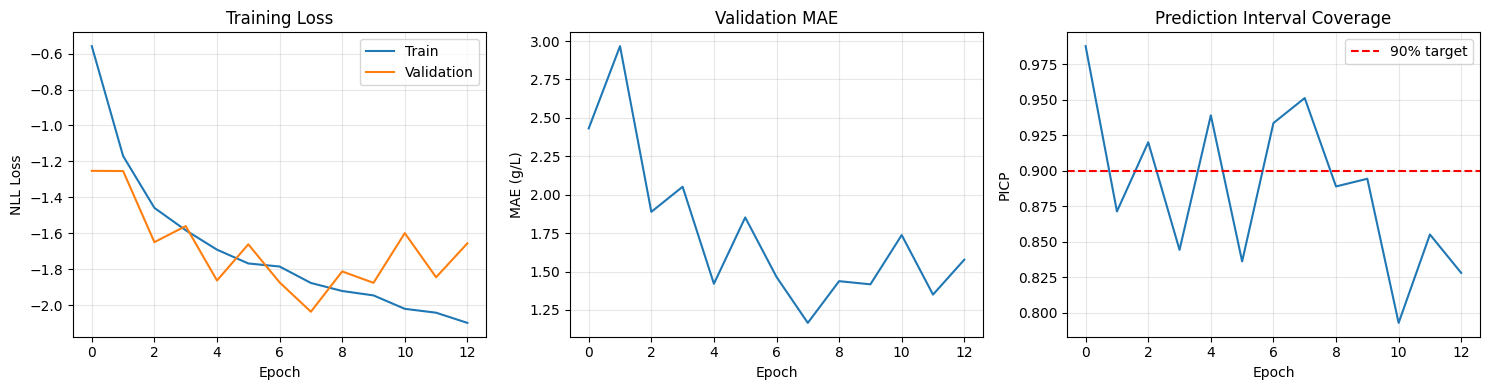

In [27]:
# Plot training curves
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Loss
axes[0].plot(history['train_loss'], label='Train')
axes[0].plot(history['val_loss'], label='Validation')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('NLL Loss')
axes[0].set_title('Training Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# MAE
axes[1].plot(history['val_mae'])
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE (g/L)')
axes[1].set_title('Validation MAE')
axes[1].grid(True, alpha=0.3)

# PICP
axes[2].plot(history['val_picp'])
axes[2].axhline(y=0.90, color='r', linestyle='--', label='90% target')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('PICP')
axes[2].set_title('Prediction Interval Coverage')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Evaluation

In [28]:
# Evaluate on all splits
train_metrics = evaluate_tft(model, data['train'], loss_fn, device)
val_metrics = evaluate_tft(model, data['val'], loss_fn, device)
target_metrics = evaluate_tft(model, data['target'], loss_fn, device)

print('=== Final Results ===')
print(f'\nSource (Train):')
print(f'  MAE:  {train_metrics["mae"]:.3f} g/L')
print(f'  RMSE: {train_metrics["rmse"]:.3f} g/L')
print(f'  PICP: {train_metrics["picp"]:.2%}')
print(f'  MPIW: {train_metrics["mpiw"]:.3f} g/L')

print(f'\nSource (Val):')
print(f'  MAE:  {val_metrics["mae"]:.3f} g/L')
print(f'  RMSE: {val_metrics["rmse"]:.3f} g/L')
print(f'  PICP: {val_metrics["picp"]:.2%}')
print(f'  MPIW: {val_metrics["mpiw"]:.3f} g/L')

print(f'\nTarget (APC):')
print(f'  MAE:  {target_metrics["mae"]:.3f} g/L')
print(f'  RMSE: {target_metrics["rmse"]:.3f} g/L')
print(f'  PICP: {target_metrics["picp"]:.2%}')
print(f'  MPIW: {target_metrics["mpiw"]:.3f} g/L')

=== Final Results ===

Source (Train):
  MAE:  0.805 g/L
  RMSE: 1.060 g/L
  PICP: 98.16%
  MPIW: 5.306 g/L

Source (Val):
  MAE:  1.166 g/L
  RMSE: 1.511 g/L
  PICP: 95.12%
  MPIW: 6.756 g/L

Target (APC):
  MAE:  1.091 g/L
  RMSE: 1.413 g/L
  PICP: 95.29%
  MPIW: 5.866 g/L


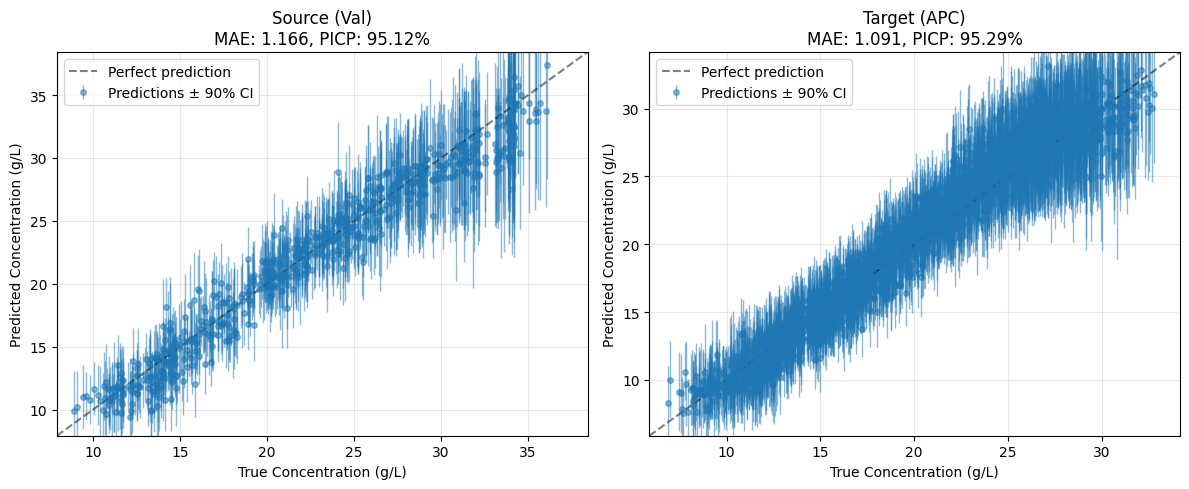

In [29]:
# Prediction vs actual plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (name, metrics) in zip(axes, [('Source (Val)', val_metrics), ('Target (APC)', target_metrics)]):
    y_true = metrics['y']
    y_pred = metrics['mu']
    sigma = metrics['sigma']
    
    # Sort by true value for better visualization
    idx = np.argsort(y_true)
    y_true = y_true[idx]
    y_pred = y_pred[idx]
    sigma = sigma[idx]
    
    # Plot predictions with error bars
    ax.errorbar(
        y_true, y_pred, yerr=1.645 * sigma,
        fmt='o', alpha=0.5, markersize=4, elinewidth=1,
        label='Predictions ± 90% CI'
    )
    
    # Perfect prediction line
    lims = [min(y_true.min(), y_pred.min()) - 1, max(y_true.max(), y_pred.max()) + 1]
    ax.plot(lims, lims, 'k--', alpha=0.5, label='Perfect prediction')
    
    ax.set_xlabel('True Concentration (g/L)')
    ax.set_ylabel('Predicted Concentration (g/L)')
    ax.set_title(f'{name}\nMAE: {metrics["mae"]:.3f}, PICP: {metrics["picp"]:.2%}')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xlim(lims)
    ax.set_ylim(lims)

plt.tight_layout()
plt.show()

## 5. Interpretability Analysis

In [32]:
# Get feature names
feature_names = list(data['stats']['features']) + ['conc_ffill', 'conc_mask', 'conc_time_since']
print(f'Features ({len(feature_names)}):')
for i, name in enumerate(feature_names):
    print(f'  {i}: {name}')

Features (28):
  0: Fg
  1: Fs
  2: Fw
  3: pressure
  4: Fpaa
  5: Foil
  6: Fa
  7: Fh
  8: Fremoved
  9: Fb
  10: Fc
  11: S
  12: OUR
  13: O2
  14: pH
  15: T
  16: DO2
  17: V
  18: Wt
  19: CO2outgas
  20: CER
  21: PAA_offline
  22: NH3_offline
  23: X_offline
  24: Viscosity_offline
  25: conc_ffill
  26: conc_mask
  27: conc_time_since


In [ ]:
# Extract interpretability information
model.eval()
all_vsn_weights = []
all_attn_weights = []

with torch.no_grad():
    for batch in data['val']:
        x = batch['x'].to(device)
        horizon = batch['D_steps'].to(device)
        mask = batch['mask'].to(device)
        
        result = model.get_interpretability(x, horizon, mask=mask)
        
        # Average VSN weights over time (excluding padded positions)
        vsn_w = result['vsn_weights'].cpu().numpy()  # (B, T, C)
        for i in range(len(vsn_w)):
            valid_len = (~batch['mask'][i]).sum().item()
            avg_weights = vsn_w[i, :valid_len, :].mean(axis=0)
            all_vsn_weights.append(avg_weights)
        
        all_attn_weights.append(result['attention_weights'].cpu().numpy())

all_vsn_weights = np.array(all_vsn_weights)
mean_vsn_weights = all_vsn_weights.mean(axis=0)

print(f'VSN weights shape: {all_vsn_weights.shape}')
print(f'Mean weights sum: {mean_vsn_weights.sum():.4f}')

In [ ]:
# Variable importance plot
fig, ax = plt.subplots(figsize=(12, 6))

# Sort by importance
idx = np.argsort(mean_vsn_weights)[::-1]
sorted_names = [feature_names[i] for i in idx]
sorted_weights = mean_vsn_weights[idx]

ax.barh(range(len(sorted_names)), sorted_weights, color='steelblue')
ax.set_yticks(range(len(sorted_names)))
ax.set_yticklabels(sorted_names)
ax.invert_yaxis()
ax.set_xlabel('Variable Importance (VSN Weight)')
ax.set_title('TFT Variable Importance')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

In [ ]:
# Top 10 most important variables
print('Top 10 Most Important Variables:')
for i in range(min(10, len(sorted_names))):
    print(f'  {i+1}. {sorted_names[i]}: {sorted_weights[i]:.4f}')

In [ ]:
# Temporal attention heatmap for a single sample
# Get a single sample
for batch in data['val']:
    x = batch['x'][:1].to(device)
    horizon = batch['D_steps'][:1].to(device)
    mask = batch['mask'][:1].to(device)
    valid_len = (~batch['mask'][0]).sum().item()
    break

with torch.no_grad():
    result = model.get_interpretability(x, horizon, mask=mask)
    attn = result['attention_weights'][0].cpu().numpy()  # (n_heads, T, T)

# Average over heads
attn_avg = attn.mean(axis=0)[:valid_len, :valid_len]

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(attn_avg, cmap='Blues', aspect='auto')
ax.set_xlabel('Key Position (Time)')
ax.set_ylabel('Query Position (Time)')
ax.set_title(f'Temporal Attention Heatmap (Sample, T={valid_len}, D={horizon[0].item()} steps)')
plt.colorbar(im, ax=ax, label='Attention Weight')

plt.tight_layout()
plt.show()

In [ ]:
torch.save({
    'model_state_dict': model.state_dict(),
    'model_config': model_config,
    'n_features': data['n_features'],
    'stats': data['stats'],
    'history': history,
}, '../models/tft_model.pt')